# 🎬 Movie Recommender System

A content-based movie recommendation system built on the **IMDB Top 1000** dataset. Given a movie title, it suggests the 5 most similar movies based on genre, director, and cast.

![Python](https://img.shields.io/badge/Python-3.10-blue?logo=python&logoColor=white)
![scikit-learn](https://img.shields.io/badge/scikit--learn-ML-orange?logo=scikitlearn&logoColor=white)
![Pandas](https://img.shields.io/badge/Pandas-Data-150458?logo=pandas&logoColor=white)
![Status](https://img.shields.io/badge/Status-Complete-brightgreen)

---

## 📌 Overview

This project builds a **content-based recommender system**: instead of using user ratings, it recommends movies that are similar in *content* — genre, director, and leading actors.

## 🧩 Pipeline

| Step | What happens |
|---|---|
| 🧹 **Data cleaning** | Drop irrelevant columns, keep only `Genre`, `Director`, `Star1-4` |
| 🏷️ **Genre encoding** | `MultiLabelBinarizer` (one-hot for multi-label genres) |
| 🔢 **Cast/Director encoding** | `LabelEncoder` (single-value categorical) |
| ⚖️ **Scaling** | `MinMaxScaler` so no feature dominates distance calculations |
| ✂️ **Train/test split** | 80% train, 20% test |
| 🤖 **Models** | `NearestNeighbors` (KNN) and `cosine_similarity` |
| 📊 **Evaluation** | Custom Genre Precision@5 metric (no ground-truth labels exist for this unsupervised task) |
| 🎨 **Visualization** | Scatter plots highlighting the query movie (⭐) and its top-5 recommendations (●) |

## 🛠️ Tech Stack
- `pandas`, `numpy` — data handling
- `matplotlib` — visualization
- `scikit-learn` — encoding, scaling, KNN, cosine similarity

## 🚀 How to run
1. Place `imdb_top_1000.csv` in the same folder as this notebook
2. Run all cells top to bottom (Kernel → Restart & Run All)
3. Change `sample_title` in the recommendation cell to test any movie you like

---

# Imports

In [59]:
# Import required libraries: data handling, visualization, and ML tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

# Load data and drop unnecessary columns

In [60]:
# Load the dataset
DataSet = pd.read_csv('imdb_top_1000.csv')

# Keep only columns relevant to content-based similarity
DataSet.drop(columns=[
    'Poster_Link', 'Released_Year', 'Certificate', 'Runtime',
    'Overview', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross'
], inplace=True)

# Keep a lookup of the original (raw text) genres for later evaluation
raw_genre_lookup = dict(zip(DataSet['Series_Title'], DataSet['Genre']))

# Use the movie title as the row index so we can access rows by name later
DataSet.rename(index=DataSet['Series_Title'], inplace=True)
DataSet.drop(columns=['Series_Title'], inplace=True)

print("Number of movies:", DataSet.shape[0])
DataSet.head(7)


Number of movies: 1000


,Genre,Director,Star1,Star2,Star3,Star4
The Shawshank Redemption,Drama,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
The Godfather,"Crime, Drama",Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton
The Dark Knight,"Action, Crime, Drama",Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
The Godfather: Part II,"Crime, Drama",Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
12 Angry Men,"Crime, Drama",Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler
The Lord of the Rings: The Return of the King,"Action, Adventure, Drama",Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom
Pulp Fiction,"Crime, Drama",Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis


In [61]:
raw_genre_lookup

{'The Shawshank Redemption': 'Drama',
 'The Godfather': 'Crime, Drama',
 'The Dark Knight': 'Action, Crime, Drama',
 'The Godfather: Part II': 'Crime, Drama',
 '12 Angry Men': 'Crime, Drama',
 'The Lord of the Rings: The Return of the King': 'Action, Adventure, Drama',
 'Pulp Fiction': 'Crime, Drama',
 "Schindler's List": 'Biography, Drama, History',
 'Inception': 'Action, Adventure, Sci-Fi',
 'Fight Club': 'Drama',
 'The Lord of the Rings: The Fellowship of the Ring': 'Action, Adventure, Drama',
 'Forrest Gump': 'Drama, Romance',
 'Il buono, il brutto, il cattivo': 'Western',
 'The Lord of the Rings: The Two Towers': 'Action, Adventure, Drama',
 'The Matrix': 'Action, Sci-Fi',
 'Goodfellas': 'Biography, Crime, Drama',
 'Star Wars: Episode V - The Empire Strikes Back': 'Action, Adventure, Fantasy',
 "One Flew Over the Cuckoo's Nest": 'Drama',
 'Hamilton': 'Biography, Drama, History',
 'Gisaengchung': 'Comedy, Drama, Thriller',
 'Soorarai Pottru': 'Drama',
 'Interstellar': 'Adventure, D

# Clean text columns

In [62]:
text_cols = ['Director', 'Star1', 'Star2', 'Star3', 'Star4']

# Replace spaces with underscores for consistency (does not affect the result)
for col in text_cols:
    DataSet[col] = DataSet[col].str.replace(' ', '_')

# One-hot encode Genre

Genres found: 21


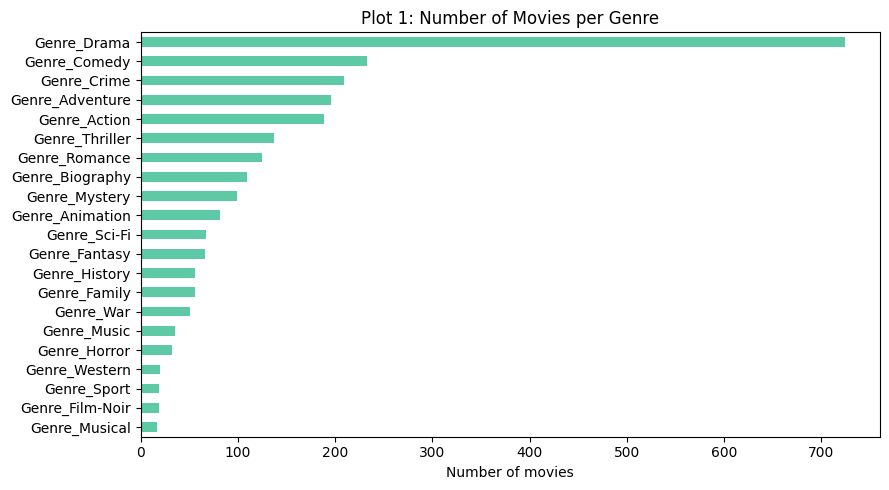

In [63]:
# Split the genre string into a list, since a movie can have multiple genres
genre_lists = DataSet['Genre'].str.split(', ')

# MultiLabelBinarizer creates one binary column per genre (not one column per
# unique genre COMBINATION, which is what a plain OneHotEncoder would do)
mlb = MultiLabelBinarizer()
genre_onehot_raw = pd.DataFrame(
    mlb.fit_transform(genre_lists),
    columns=[f'Genre_{g}' for g in mlb.classes_],
    index=DataSet.index
)

print("Genres found:", genre_onehot_raw.shape[1])

DataSet.drop(columns=['Genre'], inplace=True)

# ----- Plot 1: how many movies each genre appears in -----
plt.figure(figsize=(9, 5))
genre_onehot_raw.sum().sort_values(ascending=True).plot(kind='barh', color='#5DCAA5')
plt.xlabel('Number of movies')
plt.title('Plot 1: Number of Movies per Genre')
plt.tight_layout()
plt.show()

In [64]:
genre_onehot_raw.head(3)

,Genre_Action,Genre_Adventure,Genre_Animation,Genre_Biography,Genre_Comedy,Genre_Crime,Genre_Drama,Genre_Family,Genre_Fantasy,Genre_Film-Noir,...,Genre_Horror,Genre_Music,Genre_Musical,Genre_Mystery,Genre_Romance,Genre_Sci-Fi,Genre_Sport,Genre_Thriller,Genre_War,Genre_Western
The Shawshank Redemption,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
The Godfather,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
The Dark Knight,1,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [65]:
DataSet.head(3)

,Director,Star1,Star2,Star3,Star4
The Shawshank Redemption,Frank_Darabont,Tim_Robbins,Morgan_Freeman,Bob_Gunton,William_Sadler
The Godfather,Francis_Ford_Coppola,Marlon_Brando,Al_Pacino,James_Caan,Diane_Keaton
The Dark Knight,Christopher_Nolan,Christian_Bale,Heath_Ledger,Aaron_Eckhart,Michael_Caine


# Label encode Director and Stars

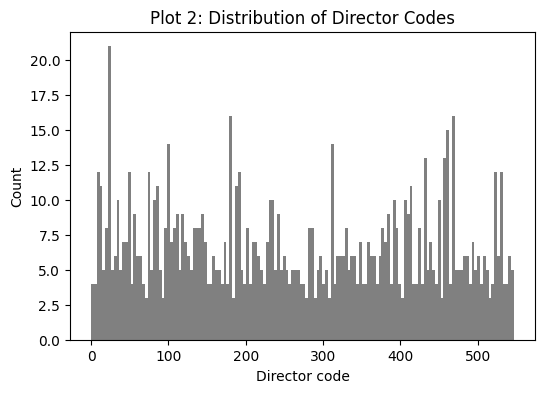

In [66]:
# Each movie has exactly ONE director and ONE actor per Star column,
# so a simple LabelEncoder (one number per name) is enough here
#text_cols = ['Director', 'Star1', 'Star2', 'Star3', 'Star4']                           
encoders = {}
for col in text_cols:
    label_encoder = LabelEncoder()
    DataSet[col] = label_encoder.fit_transform(DataSet[col])
    encoders[col] = label_encoder

plt.figure(figsize=(6, 4))
plt.hist(DataSet['Director'], bins=150, color='grey')
plt.xlabel('Director code')
plt.ylabel('Count')
plt.title('Plot 2: Distribution of Director Codes')
plt.show()

# Scale the encoded columns

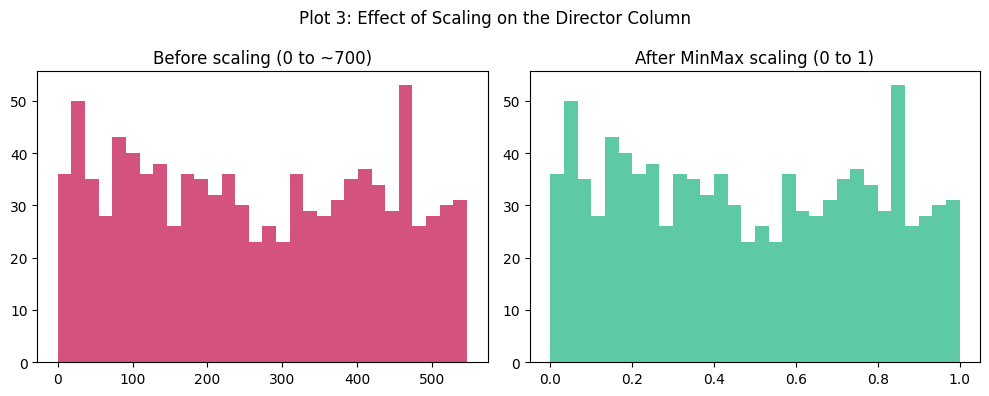

In [67]:
# Director/Star codes can range up to ~700, while genre columns are only 0/1.
# Without scaling, distance calculations would be dominated by these codes
# and the genre information would barely matter — so we rescale to [0, 1].
scaler = MinMaxScaler()
scaled_text_cols = pd.DataFrame(
    scaler.fit_transform(DataSet[text_cols]),
    columns=text_cols,
    index=DataSet.index
)

# ----- Plot 3: before vs after scaling (Director column) -----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(DataSet['Director'], bins=30, color='#D4537E')
axes[0].set_title('Before scaling (0 to ~700)')

axes[1].hist(scaled_text_cols['Director'], bins=30, color='#5DCAA5')
axes[1].set_title('After MinMax scaling (0 to 1)')

plt.suptitle('Plot 3: Effect of Scaling on the Director Column')
plt.tight_layout()
plt.show()

In [68]:
scaled_text_cols.head(5)

,Director,Star1,Star2,Star3,Star4
The Shawshank Redemption,0.257770,0.908953,0.676190,0.100000,0.972281
The Godfather,0.250457,0.632777,0.010714,0.377528,0.206823
The Dark Knight,0.151737,0.194234,0.336905,0.001124,0.660981
The Godfather: Part II,0.250457,0.013657,0.782143,0.791011,0.206823
12 Angry Men,0.833638,0.382398,0.552381,0.601124,0.448827


# Combine into the final feature matrix

In [69]:
# Merge the scaled director/star columns with the one-hot genre columns
Features = pd.concat([scaled_text_cols, genre_onehot], axis=1)
Features.shape

(1000, 26)

In [70]:
Features.head(3)

,Director,Star1,Star2,Star3,Star4,Genre_Action,Genre_Adventure,Genre_Animation,Genre_Biography,Genre_Comedy,...,Genre_Horror,Genre_Music,Genre_Musical,Genre_Mystery,Genre_Romance,Genre_Sci-Fi,Genre_Sport,Genre_Thriller,Genre_War,Genre_Western
The Shawshank Redemption,0.257770,0.908953,0.676190,0.100000,0.972281,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
The Godfather,0.250457,0.632777,0.010714,0.377528,0.206823,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
The Dark Knight,0.151737,0.194234,0.336905,0.001124,0.660981,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Train/test split

Training movies: 800
Test movies: 200


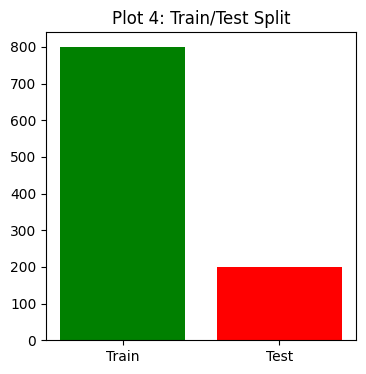

In [71]:
train_set, test_set = train_test_split(Features, test_size=0.2, random_state=42)
x_train = train_set.values

print("Training movies:", len(train_set))
print("Test movies:", len(test_set))

# ----- Plot 4: train/test sample counts -----
plt.figure(figsize=(4, 4))
plt.bar(['Train', 'Test'], [len(train_set), len(test_set)], color=['green', 'red'])
plt.title('Plot 4: Train/Test Split')
plt.show()

# Model 1: KNN (NearestNeighbors)

In [72]:
# n_neighbors=6 because the query movie itself may be its own nearest neighbor
# during evaluation; we drop it later to keep exactly 5 real recommendations
knn_model = NearestNeighbors(n_neighbors=6, metric='euclidean')
knn_model.fit(x_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'eu...an'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


# Model 2: Cosine similarity matrix

Cosine similarity matrix shape: (800, 800)


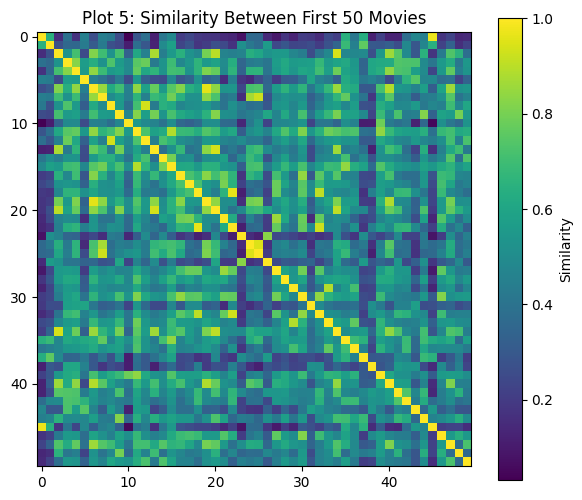

In [73]:
# Precompute similarity between every pair of training movies at once
cosine_sim_matrix = cosine_similarity(x_train)
print("Cosine similarity matrix shape:", cosine_sim_matrix.shape)

# ----- Plot 5: similarity heatmap for the first 50 movies -----
plt.figure(figsize=(7, 6))
plt.imshow(cosine_sim_matrix[:50, :50], cmap='viridis')
plt.colorbar(label='Similarity')
plt.title('Plot 5: Similarity Between First 50 Movies')
plt.show()

# Recommendation functions (support train and test movies)

In [74]:
def get_feature_vector(title):
    """Return the feature vector of a movie, whether it's in train_set or test_set."""
    if title in train_set.index:
        return train_set.loc[[title]].values
    elif title in test_set.index:
        return test_set.loc[[title]].values
    else:
        print(f"'{title}' was not found in train_set or test_set.")
        return None


def recommend_knn(title, n=5):
    """Recommend n similar movies using the KNN model (Euclidean distance)."""
    sample = get_feature_vector(title)
    if sample is None:
        return None
    # The model only searches among training movies (it was fit on x_train)
    distances, indices = knn_model.kneighbors(sample, n_neighbors=n + 1)
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        neighbor_title = train_set.index[idx]
        if neighbor_title != title:  # exclude the query movie itself
            results.append((neighbor_title, dist))
    return results[:n]


def recommend_cosine(title, n=5):
    """Recommend n similar movies using cosine similarity."""
    sample = get_feature_vector(title)
    if sample is None:
        return None
    # Compute similarity live against all training movies
    sim_scores = cosine_similarity(sample, x_train)[0]
    sorted_idx = np.argsort(sim_scores)[::-1]
    results = []
    for idx in sorted_idx:
        neighbor_title = train_set.index[idx]
        if neighbor_title != title:
            results.append((neighbor_title, sim_scores[idx]))
        if len(results) == n:
            break
    return results

**We know these**

In [75]:
title = test_set.index[0]
test_set.loc[[title]].values

array([[0.51736746, 0.51441578, 0.99642857, 0.47865169, 0.08848614,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 1.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ]])

In [76]:
print(test_set.loc[[title]].values.shape)
print(test_set.loc[[title]].values.ndim)

(1, 26)
2


In [77]:
sample_title = test_set.index[5]      # or index[0]  or ....
print(f"فیلم ورودی (از داده تست): {sample_title}")

فیلم ورودی (از داده تست): Evil Dead II


# Try it on a movie from the test set

In [80]:
knn_results = recommend_knn(sample_title)
cosine_results = recommend_cosine(sample_title)

knn_titles = [t for t, d in knn_results]
knn_distances = [d for t, d in knn_results]

cosine_titles = [t for t, s in cosine_results]
cosine_scores = [s for t, s in cosine_results]

print("\nKNN recommendations:")
for t, d in knn_results:
    print(f"  - {t}  (distance: {d:.3f})")

print("\nCosine recommendations:")
for t, s in cosine_results:
    print(f"  - {t}  (similarity: {s:.3f})")


KNN recommendations:
  - Kung fu  (distance: 0.999)
  - Ghostbusters  (distance: 1.074)
  - Thor: Ragnarok  (distance: 1.425)
  - About Time  (distance: 1.428)
  - Kick-Ass  (distance: 1.462)

Cosine recommendations:
  - Kung fu  (similarity: 0.927)
  - Ghostbusters  (similarity: 0.869)
  - Thor: Ragnarok  (similarity: 0.792)
  - About Time  (similarity: 0.778)
  - Hera Pheri  (similarity: 0.764)


# Bar charts of the recommendation scores

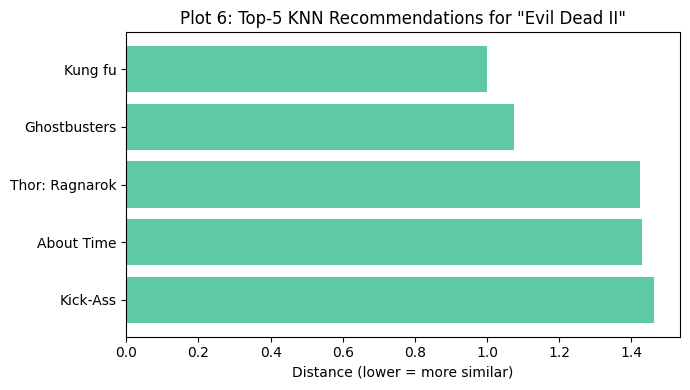

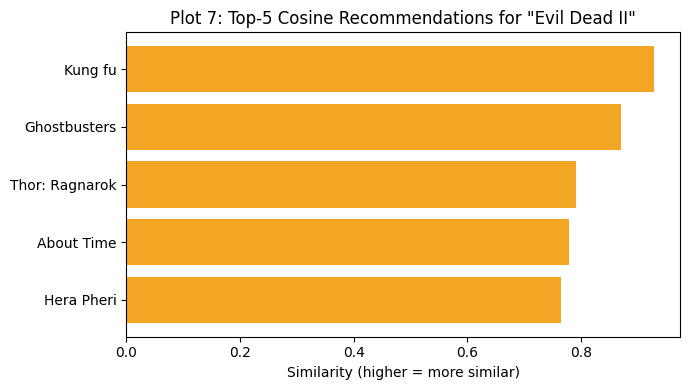

In [81]:
# ----- Plot 6: top-5 KNN recommendations -----
plt.figure(figsize=(7, 4))
plt.barh(knn_titles[::-1], knn_distances[::-1], color='#5DCAA5')
plt.xlabel('Distance (lower = more similar)')
plt.title(f'Plot 6: Top-5 KNN Recommendations for "{sample_title}"')
plt.tight_layout()
plt.show()

# ----- Plot 7: top-5 cosine recommendations -----
plt.figure(figsize=(7, 4))
plt.barh(cosine_titles[::-1], cosine_scores[::-1], color='#F2A623')
plt.xlabel('Similarity (higher = more similar)')
plt.title(f'Plot 7: Top-5 Cosine Recommendations for "{sample_title}"')
plt.tight_layout()
plt.show()

# Custom evaluation metric (no ground-truth labels available)

In [82]:
query_vector = get_feature_vector(sample_title)[0]
query_x, query_y = query_vector[0], query_vector[1]

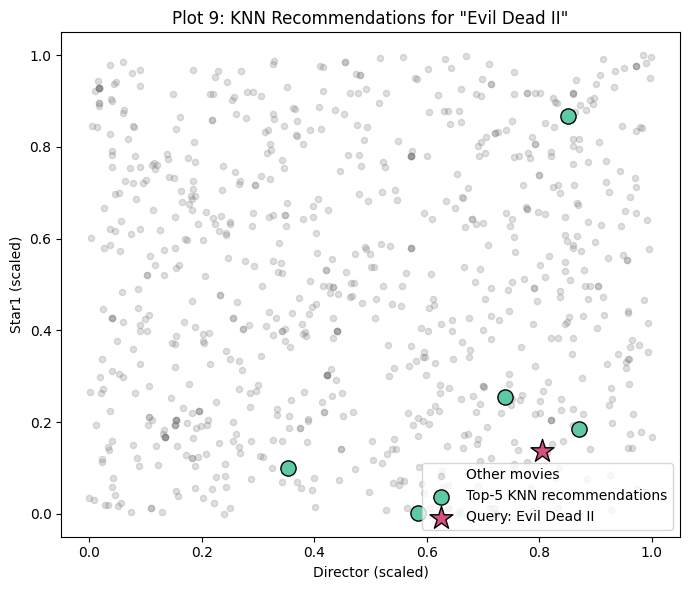

In [83]:
# ----- پلات 1: نتیجهٔ مدل KNN -----
plt.figure(figsize=(7, 6))

# همهٔ فیلم‌های آموزشی به‌عنوان پس‌زمینه (خاکستری کم‌رنگ)
plt.scatter(train_set['Director'], train_set['Star1'], color='gray', alpha=0.25, s=20, label='Other movies')

# 5 فیلم پیشنهادی KNN با دایره
knn_x = [train_set.loc[t, 'Director'] for t in knn_titles]
knn_y = [train_set.loc[t, 'Star1'] for t in knn_titles]
plt.scatter(knn_x, knn_y, color='#5DCAA5', s=120, edgecolor='black', label='Top-5 KNN recommendations')

# فیلم ورودی با ستاره
plt.scatter(query_x, query_y, color='#D4537E', s=300, marker='*', edgecolor='black', label=f'Query: {sample_title}')

plt.xlabel('Director (scaled)')
plt.ylabel('Star1 (scaled)')
plt.title(f'Plot 9: KNN Recommendations for "{sample_title}"')
plt.legend()
plt.tight_layout()
plt.show()


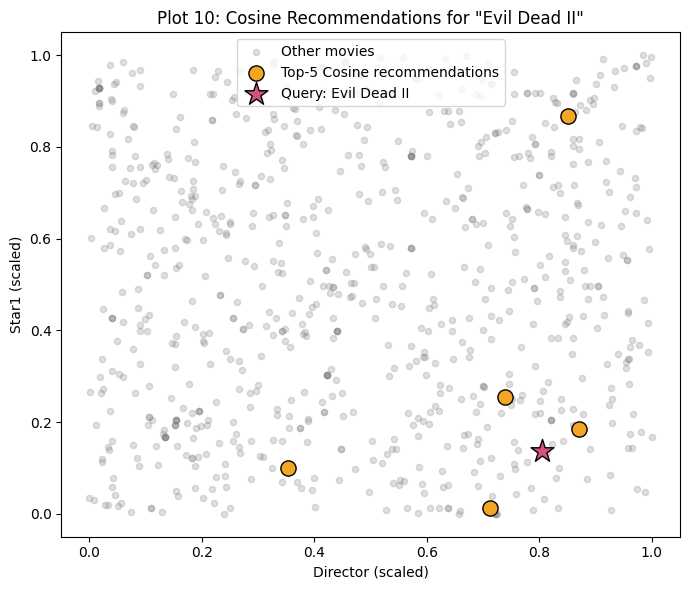

In [84]:
# ----- پلات 2: نتیجهٔ مدل Cosine -----
plt.figure(figsize=(7, 6))

plt.scatter(train_set['Director'], train_set['Star1'], color='gray', alpha=0.25, s=20, label='Other movies')

cosine_x = [train_set.loc[t, 'Director'] for t in cosine_titles]
cosine_y = [train_set.loc[t, 'Star1'] for t in cosine_titles]
plt.scatter(cosine_x, cosine_y, color='#F2A623', s=120, edgecolor='black', label='Top-5 Cosine recommendations')

plt.scatter(query_x, query_y, color='#D4537E', s=300, marker='*', edgecolor='black', label=f'Query: {sample_title}')

plt.xlabel('Director (scaled)')
plt.ylabel('Star1 (scaled)')
plt.title(f'Plot 10: Cosine Recommendations for "{sample_title}"')
plt.legend()
plt.tight_layout()
plt.show()